In [105]:
# Cell 1

from pathlib import Path
import copy
import os
import subprocess

import yaml

In [106]:
# Cell 2

def find_project_root():
    current = Path.cwd()

    for parent in [current] + list(current.parents):
        if (parent / "config.yaml").exists():
            return parent

    raise FileNotFoundError("config.yaml not found")

PROJECT_ROOT = find_project_root()
BASE_CONFIG = PROJECT_ROOT / "config.yaml"
RUN_CONFIG = PROJECT_ROOT / "config.run.yaml"

print("Project root:", PROJECT_ROOT)
print("Base config:", BASE_CONFIG)
print("Run config:", RUN_CONFIG)

Project root: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape
Base config: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/config.yaml
Run config: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/config.run.yaml


In [107]:
# Cell 3
with open(BASE_CONFIG, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# cfg

In [108]:
# Cell 4

run_cfg = copy.deepcopy(cfg)

# --- Edit values here --------------------------------------------------------

# Region
# run_cfg["region"]["name"] = "falkland_islands"
# run_cfg["region"]["bbox"]["xmin"] = -64
# run_cfg["region"]["bbox"]["ymin"] = -57
# run_cfg["region"]["bbox"]["xmax"] = -51
# run_cfg["region"]["bbox"]["ymax"] = -47
# run_cfg["region"]["buffer_km"] = 50

# Grid
# run_cfg["grid"]["resolution"] = 6

# Time
# run_cfg["time"]["start"] = "2014-01-01"
# run_cfg["time"]["end"] = "2023-12-31"

# run_cfg

In [109]:
# Cell 5

with open(RUN_CONFIG, "w", encoding="utf-8") as f:
    yaml.safe_dump(run_cfg, f, sort_keys=False, allow_unicode=False)

print(f"Wrote run config: {RUN_CONFIG}")

Wrote run config: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/config.run.yaml


In [110]:
# Cell 6

RUN = {
    "grid": True,
    "downloads": False,
    "preprocessing": False,
    "dataset": False,
    "model": False,
    "validation": False,
}

print("Execution plan:")
for stage, flag in RUN.items():
    state = "ON" if flag else "OFF"
    print(f"  {stage}: {state}")

Execution plan:
  grid: ON
  downloads: OFF
  preprocessing: OFF
  dataset: OFF
  model: OFF
  validation: OFF


In [111]:
# Cell 7

def run_script(script_name):
    """Run a script using config.run.yaml."""
    env = os.environ.copy()
    env["RISKCAPE_CONFIG"] = RUN_CONFIG.name

    subprocess.run(
        ["python", f"scripts/{script_name}"],
        check=True,
        env=env,
        cwd=PROJECT_ROOT,
    )

In [112]:
# Cell 8

if RUN["grid"]:
    print("Running grid stage...")
    # run_script("build_grid.py")
    print("Grid stage complete.")
else:
    print("Grid stage skipped.")

Running grid stage...
Grid stage complete.


In [113]:
# Cell 9

import pandas as pd

grid_dir = (PROJECT_ROOT / run_cfg["paths"]["grids"]).resolve()

grid_file = next(grid_dir.glob("*.parquet"))

df = pd.read_parquet(grid_file)

print("Grid file:", grid_file.name)
print("Columns:", list(df.columns))

df.head()

Grid file: h3_res6_falkland_islands.parquet
Columns: ['id', 'lat', 'lon', 'geometry']


,id,lat,lon,geometry
0,86df5264fffffff,-55.737142,-59.320971,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
1,86de64037ffffff,-51.712367,-63.354056,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
2,86de2c49fffffff,-55.398613,-57.658710,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
3,86de56997ffffff,-51.329172,-54.218699,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
4,86de72ce7ffffff,-52.106154,-56.368908,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...


In [114]:
# Cell 10

n_cells = len(df)

print("Number of cells:", n_cells)

Number of cells: 37209


In [115]:
# Cell 11

if {"lon", "lat"}.issubset(df.columns):
    lon = df["lon"]
    lat = df["lat"]

elif {"longitude", "latitude"}.issubset(df.columns):
    lon = df["longitude"]
    lat = df["latitude"]

elif "h3_index" in df.columns:
    import h3

    lon = df["h3_index"].apply(lambda h: h3.cell_to_lng(h))
    lat = df["h3_index"].apply(lambda h: h3.cell_to_lat(h))

else:
    raise ValueError("No spatial columns found")

print("Extent:")
print(f"  xmin: {lon.min()}")
print(f"  xmax: {lon.max()}")
print(f"  ymin: {lat.min()}")
print(f"  ymax: {lat.max()}")

Extent:
  xmin: -64.73146023886804
  xmax: -50.27152104567094
  ymin: -57.45007038413523
  ymax: -46.5495958408838


Text(0.5, 1.0, 'H3 Grid (centroids) + Original BBOX')

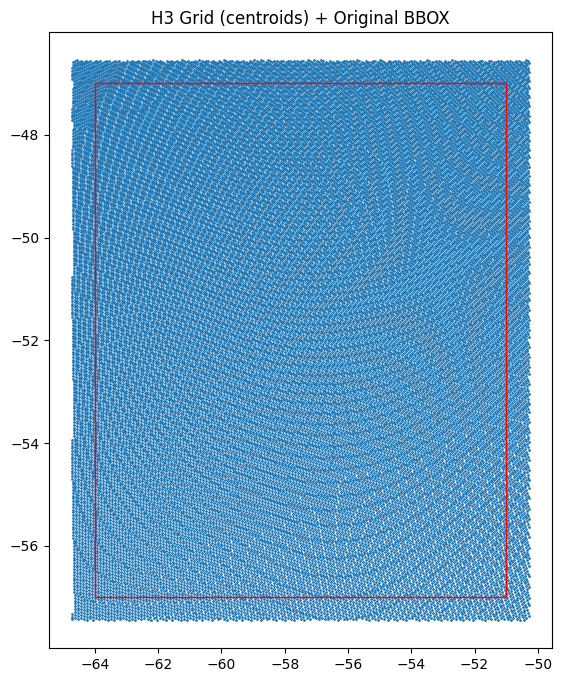

In [ ]:
# Cell 12

import geopandas as gpd
from shapely.geometry import Point, box

# Grid points
gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(lon, lat)],
    crs="EPSG:4326",
)

# Original bbox (NO buffer)
bbox = run_cfg["region"]["bbox"]

bbox_poly = box(
    bbox["xmin"],
    bbox["ymin"],
    bbox["xmax"],
    bbox["ymax"],
)

bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

# Plot
ax = gdf.plot(markersize=1, figsize=(8, 8))

bbox_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=1)

ax.set_title("H3 Grid (centroids) + Original BBOX")
